<p style="font-size: 20px;">
<b>Student Full Name:</b> Jasser Dhaouadi <br>
<b>Student ID:</b> U89818600 <br>
<b>Course:</b> Data Science Capstone - 1 <br>
<b>Semester:</b> Summer 2026 <br>
<b>Program:</b> OMDS <br>
<b>Boston University</b> 
</p>

# Week 3 - Linear Regression: Part 3 | Forward / Backward Selection & Principal Component

# Homework - Working On My Datasets

### Packages

In [48]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.base import BaseEstimator, ClassifierMixin

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    average_precision_score,
)

from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

### IMPORTANT NOTE:

- In this notebook I am applying the Week 3 concepts to my datasets.

- The content includes **forward selection**, **backward selection**, **principal component regression**, and **partial least squares regression**. 

- Since all the targets of my datasets are **categorical**, the methods are adapted for **classification**:

    - **Forward and backward selection use logistic regression**
    - **PCR is adapted as PCA followed by logistic regression**
    - **PLSR is adapted as a PLS-style discriminant model**

- The goal is to compare **feature selection and dimension-reduction approaches** on the same diabetes (dataset1) / obesity(dataset2) / cervical cancer (dataset3) classification task.

## Dataset 1: CDC Diabetes Health Indicators  (sourced from BRFSS) 

#### [Dataset 1] | *1- Load the dataset*

In [2]:
diabetes_path = "diabetes_012_health_indicators_BRFSS2015.csv"

df_diabetes = pd.read_csv(diabetes_path)

print("Dataset shape:", df_diabetes.shape)
display(df_diabetes.head())

target = "Diabetes_012"

class_counts = df_diabetes[target].value_counts().sort_index()
display(class_counts.to_frame("Class Count"))

Dataset shape: (253680, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


,Class Count
Diabetes_012,
0.0,213703
1.0,4631
2.0,35346



- The **target** is highly **imbalanced**:
    - Class 0 dominates the dataset
    - while class 1 is very rare

- Because of this, accuracy alone is not enough: Balanced accuracy, macro F1, and multiclass ROC AUC are used to better evaluate the models.

#### [Dataset 1] | *2- Train-test split*

In [3]:
X = df_diabetes.drop(columns=[target])
y = df_diabetes[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

display(y_train.value_counts().sort_index().to_frame("Train Class Count"))
display(y_test.value_counts().sort_index().to_frame("Test Class Count"))

Training shape: (202944, 21)
Testing shape: (50736, 21)


,Train Class Count
Diabetes_012,
0,170962
1,3705
2,28277


,Test Class Count
Diabetes_012,
0,42741
1,926
2,7069


- The data was split into training and testing sets using **stratification**.


| Split | Shape |
|---|---:|
| Training | (202,944, 21) |
| Testing | (50,736, 21) |


- **Stratification** is important because the prediabetes class is very small
    - This keeps the **class distribution similar in both the training and testing sets**.

#### [Dataset 1] | *3- Create a smaller selection sample*

In [4]:
_, X_model_select, _, y_model_select = train_test_split(
    X_train,
    y_train,
    test_size=2500,
    random_state=42,
    stratify=y_train
)

X_sel_train, X_sel_valid, y_sel_train, y_sel_valid = train_test_split(
    X_model_select,
    y_model_select,
    test_size=0.30,
    random_state=42,
    stratify=y_model_select
)

print("Selection sample shape:", X_model_select.shape)
display(y_model_select.value_counts().sort_index().to_frame("Selection Sample Count"))

Selection sample shape: (2500, 21)


,Selection Sample Count
Diabetes_012,
0,2106
1,46
2,348


- A **stratified sample of 2,500 training observations** was used for **forward and backward selection**.

- The selection sample has:

| Class | Count |
|---:|---:|
| 0 | 2,106 |
| 1 | 46 |
| 2 | 348 |


**Important:**

- This sample is used only to c**hoose features efficiently**. 

- After the features are selected, the **final models are trained on the full training set** and **evaluated on the full test set**.

#### [Dataset 1] | *4- Forward and backward selection functions*

In [5]:
fast_selection_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(
            max_iter=80,
            tol=0.10,
            class_weight="balanced",
            solver="lbfgs"
        ))
    ]
)

def score_feature_set(features):
    fast_selection_model.fit(X_sel_train[features], y_sel_train)
    predictions = fast_selection_model.predict(X_sel_valid[features])
    
    return f1_score(
        y_sel_valid,
        predictions,
        average="macro"
    )


def forward_selection(feature_names, number_of_features=8):
    selected_features = []
    remaining_features = list(feature_names)
    steps = []
    
    for step in range(number_of_features):
        best_feature = None
        best_score = -1
        
        for feature in remaining_features:
            candidate_features = selected_features + [feature]
            score = score_feature_set(candidate_features)
            
            if score > best_score:
                best_score = score
                best_feature = feature
        
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        
        steps.append({
            "Step": step + 1,
            "Added Feature": best_feature,
            "Validation Macro F1": best_score
        })
    
    return selected_features, pd.DataFrame(steps)


def backward_selection(feature_names, number_of_features=8):
    current_features = list(feature_names)
    steps = []
    
    while len(current_features) > number_of_features:
        best_feature_to_remove = None
        best_score = -1
        best_remaining_features = None
        
        for feature in current_features:
            candidate_features = [
                item for item in current_features
                if item != feature
            ]
            
            score = score_feature_set(candidate_features)
            
            if score > best_score:
                best_score = score
                best_feature_to_remove = feature
                best_remaining_features = candidate_features
        
        current_features = best_remaining_features
        
        steps.append({
            "Step": len(steps) + 1,
            "Removed Feature": best_feature_to_remove,
            "Validation Macro F1": best_score,
            "Remaining Feature Count": len(current_features)
        })
    
    return current_features, pd.DataFrame(steps)

- We define the **forward and backward selection logic**:

    - **Forward selection** starts with no predictors and adds one feature at a time. 
    - **Backward selection** starts with all predictors and removes one feature at a time.

    - The **selection criterion** is validation **macro F1**. 
        - Macro F1 is used because the dataset is **imbalanced** and we do not want the largest class to dominate the feature-selection process.


#### [Dataset 1] | *5- Run forward selection*

In [6]:
all_features = X.columns.tolist()

forward_features, forward_steps = forward_selection(
    feature_names=all_features,
    number_of_features=8
)

display(forward_steps)

print("Selected forward features:")
print(forward_features)

,Step,Added Feature,Validation Macro F1
0,1,PhysHlth,0.412264
1,2,HeartDiseaseorAttack,0.434114
2,3,NoDocbcCost,0.441523
3,4,CholCheck,0.444253
4,5,Stroke,0.440772
5,6,Smoker,0.438950
6,7,Sex,0.435525
7,8,HvyAlcoholConsump,0.432093


Selected forward features:
['PhysHlth', 'HeartDiseaseorAttack', 'NoDocbcCost', 'CholCheck', 'Stroke', 'Smoker', 'Sex', 'HvyAlcoholConsump']


- The **validation macro F1** improved until step 4 and then started to decrease. 

- This shows an important **limitation of using a fixed number of selected features**: adding more variables does not always improve validation performance.

#### [Dataset 1] | *6- Run backward selection*

In [7]:
backward_features, backward_steps = backward_selection(
    feature_names=all_features,
    number_of_features=8
)

display(backward_steps)

print("Selected backward features:")
print(backward_features)

,Step,Removed Feature,Validation Macro F1,Remaining Feature Count
0,1,NoDocbcCost,0.418139,20
1,2,Sex,0.423858,19
2,3,Stroke,0.433846,18
3,4,CholCheck,0.432737,17
4,5,AnyHealthcare,0.430338,16
5,6,Veggies,0.432903,15
6,7,Smoker,0.432678,14
7,8,Income,0.432030,13
8,9,Age,0.428380,12
9,10,PhysActivity,0.430892,11


Selected backward features:
['BMI', 'HeartDiseaseorAttack', 'Fruits', 'HvyAlcoholConsump', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk']


- **Backward selection** chose a **different** set of variables from forward selection. 

- Stepwise methods do not test every possible feature combination, so the path taken by the algorithm can affect the final selected feature set

#### [Dataset 1] | *7- Evaluate all-features, forward-selection, and backward-selection models*

In [8]:
final_logistic_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="lbfgs"
        ))
    ]
)

def evaluate_multiclass_model(model_name, model, X_train_data, X_test_data):
    model.fit(X_train_data, y_train)
    
    predictions = model.predict(X_test_data)
    probabilities = model.predict_proba(X_test_data)
    
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_test, predictions),
        "Macro F1": f1_score(y_test, predictions, average="macro"),
        "Weighted F1": f1_score(y_test, predictions, average="weighted"),
        "Macro OVR ROC AUC": roc_auc_score(
            y_test,
            probabilities,
            multi_class="ovr",
            average="macro"
        )
    }, predictions


selection_metrics = []
selection_predictions = {}

for model_name, feature_set in [
    ("Baseline all features", all_features),
    ("Forward selection", forward_features),
    ("Backward selection", backward_features)
]:
    metrics, predictions = evaluate_multiclass_model(
        model_name=model_name,
        model=final_logistic_model,
        X_train_data=X_train[feature_set],
        X_test_data=X_test[feature_set]
    )
    
    selection_metrics.append(metrics)
    selection_predictions[model_name] = predictions

selection_metrics_df = pd.DataFrame(selection_metrics)

display(selection_metrics_df)

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro OVR ROC AUC
0,Baseline all features,0.645754,0.524173,0.426883,0.720590,0.772785
1,Forward selection,0.685332,0.431375,0.396876,0.730168,0.634530
2,Backward selection,0.645321,0.478817,0.410782,0.714428,0.730504


- The executed model comparison was:

| Model | Accuracy | Balanced Accuracy | Macro F1 | Weighted F1 | Macro OVR ROC AUC |
|---|---:|---:|---:|---:|---:|
| **Baseline all features** | 0.645754 | 0.524173 | 0.426883 | 0.720590 | 0.772785 |
| **Forward selection** | 0.685332 | 0.431375 | 0.396876 | 0.730168 | 0.634530 |
| **Backward selection** | 0.645321 | 0.478817 | 0.410782 | 0.714428 | 0.730504 |

- The **all-features baseline** had the **strongest macro F1** among these three models. 

- **Forward selection** had higher accuracy, but its balanced accuracy and macro F1 were worse. 
    - This suggests that forward selection improved majority-class prediction but weakened performance across all classes.

- **Backward selection** performed better than forward selection on macro F1, but it still did not outperform the full model. 

- For this diabetes dataset, removing features did not improve the main validation objective.

#### [Dataset 1] | *8- Visualize stepwise model comparison*

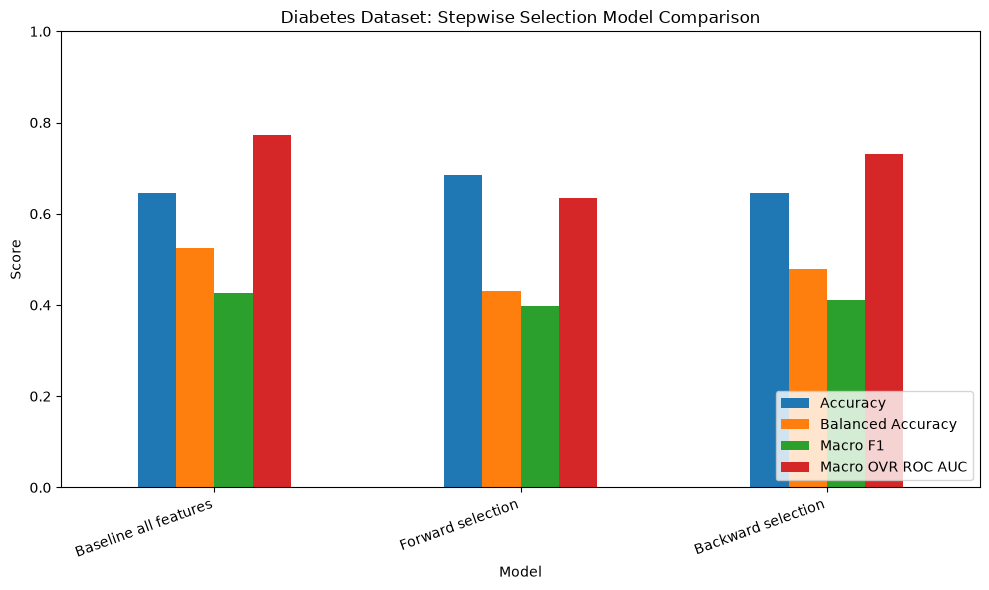

In [9]:
selection_metrics_df.set_index("Model")[
    ["Accuracy", "Balanced Accuracy", "Macro F1", "Macro OVR ROC AUC"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Diabetes Dataset: Stepwise Selection Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

- The plot shows that the f**ull model performs best overall among the stepwise-selection models**

- **Forward selection** has the highest accuracy, but this is **misleading** because the dataset is **imbalanced**

- The **full model** has the **strongest balanced accuracy**, **macro F1**, and **ROC AUC**, which makes it more reliable for this **multiclass diabetes task**

#### [Dataset 1] | *9- Tune PCR-style model*

In [10]:
_, X_component_tune, _, y_component_tune = train_test_split(
    X_train,
    y_train,
    test_size=8000,
    random_state=42,
    stratify=y_train
)

component_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

pcr_results = []

for n_components in [2, 5, 10, 15, 21]:
    pcr_model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("pca", PCA(
                n_components=n_components,
                random_state=42
            )),
            ("logit", LogisticRegression(
                max_iter=500,
                tol=0.01,
                class_weight="balanced",
                solver="lbfgs"
            ))
        ]
    )
    
    scores = cross_val_score(
        pcr_model,
        X_component_tune,
        y_component_tune,
        cv=component_cv,
        scoring="f1_macro"
    )
    
    pcr_results.append({
        "n_components": n_components,
        "Mean CV Macro F1": scores.mean(),
        "Std CV Macro F1": scores.std()
    })

pcr_results_df = pd.DataFrame(pcr_results)

display(pcr_results_df)

,n_components,Mean CV Macro F1,Std CV Macro F1
0,2,0.410192,0.003198
1,5,0.407244,0.004668
2,10,0.412315,0.002709
3,15,0.406414,0.006363
4,21,0.407444,0.004342


- The **PCR-style model** was tuned using **PCA components followed by logistic regression**

- The cross-validation results were:

| n_components | Mean CV Macro F1 | Std CV Macro F1 |
|---:|---:|---:|
| 2 | 0.410192 | 0.003198 |
| 5 | 0.407244 | 0.004668 |
| 10 | 0.412315 | 0.002709 |
| 15 | 0.406414 | 0.006363 |
| 21 | 0.407444 | 0.004342 |


- The **best number of components was 10**, with **mean CV macro F1 of 0.412315**

- This result connects directly to PCR: 
    - PCA keeps components based on **variance in the predictors**, not necessarily based on the target 
    - Therefore, using more components does not automatically improve classification performance

#### [Dataset 1] | *10- Fit and evaluate best PCR-style model*

In [11]:
best_pcr_components = int(
    pcr_results_df.loc[
        pcr_results_df["Mean CV Macro F1"].idxmax(),
        "n_components"
    ]
)

best_pcr_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("pca", PCA(
            n_components=best_pcr_components,
            random_state=42
        )),
        ("logit", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="lbfgs"
        ))
    ]
)

pcr_metrics, pcr_predictions = evaluate_multiclass_model(
    model_name=f"PCR-style logistic regression ({best_pcr_components} PCs)",
    model=best_pcr_model,
    X_train_data=X_train,
    X_test_data=X_test
)

best_pcr_model.fit(X_train, y_train)

explained_variance = (
    best_pcr_model
    .named_steps["pca"]
    .explained_variance_ratio_
)

display(pd.DataFrame([pcr_metrics]))

print("Explained variance ratio:")
print(explained_variance)

print("Total explained variance:")
print(explained_variance.sum())

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro OVR ROC AUC
0,PCR-style logistic regression (10 PCs),0.648711,0.507743,0.424194,0.722373,0.765069


Explained variance ratio:
[0.16689865 0.08419404 0.06475973 0.05680408 0.05508102 0.05176693
 0.04914306 0.04502331 0.04399867 0.04186339]
Total explained variance:
0.6595328670186759


- The best PCR-style model used **10 principal components**

- The executed test performance was:

| Model | Accuracy | Balanced Accuracy | Macro F1 | Weighted F1 | Macro OVR ROC AUC |
|---|---:|---:|---:|---:|---:|
| **PCR-style logistic regression (10 PCs)** | 0.648711 | 0.507743 | 0.424194 | 0.722373 | 0.765069 |


- The **10 selected principal components** explained about **65.95%** of the total feature variance.

- The explained variance ratios were approximately:

[0.166899, 0.084194, 0.064760, 0.056804, 0.055081, 0.051767, 0.049143, 0.045023, 0.043999, 0.041863]

- PCR performed **close** to the all-features logistic regression model but did not outperform it. 

    - This suggests that PCA reduced dimensionality, but some information useful for distinguishing diabetes classes may exist outside the highest-variance components.

#### [Dataset 1] | *11- Visualize PCA explained variance*

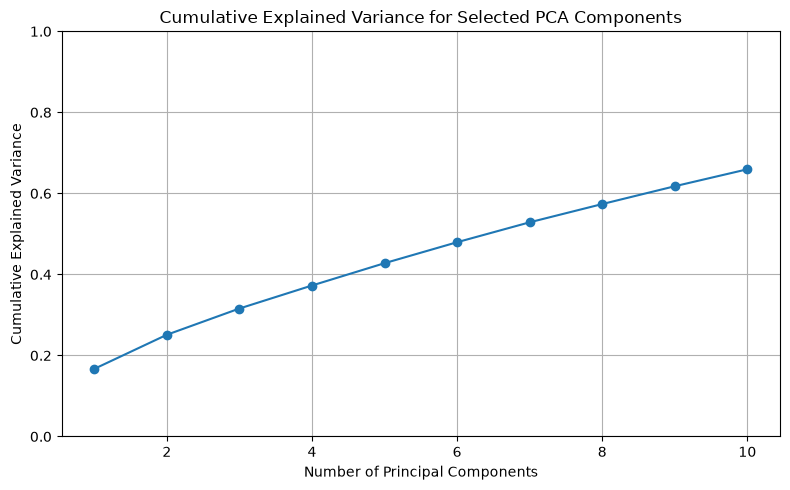

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, best_pcr_components + 1),
    explained_variance.cumsum(),
    marker="o"
)

plt.title("Cumulative Explained Variance for Selected PCA Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()

- The **cumulative explained variance** plot shows how much feature variance is retained as more principal components are added.

- The **first 10 components** explain about **65.95%** of the predictor variance. 

- This is useful for dimensionality reduction, but PCR does not guarantee better classification because PCA does not use the target variable when creating components.

#### [Dataset 1] | *12- Define PLS-style discriminant classifier*

In [13]:
class PLSDAClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, n_components=2):
        self.n_components = n_components
    
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        class_to_index = {
            label: index
            for index, label in enumerate(self.classes_)
        }
        
        Y = np.zeros((len(y), len(self.classes_)))
        
        for row_index, label in enumerate(np.asarray(y)):
            Y[row_index, class_to_index[label]] = 1
        
        self.model_ = PLSRegression(
            n_components=self.n_components,
            scale=False,
            max_iter=300,
            tol=1e-4
        )
        
        self.model_.fit(X, Y)
        
        return self
    
    def predict(self, X):
        scores = np.asarray(self.model_.predict(X))
        predicted_indexes = np.argmax(scores, axis=1)
        
        return self.classes_[predicted_indexes]
    
    def predict_proba(self, X):
        scores = np.asarray(self.model_.predict(X))
        scores = scores - scores.max(axis=1, keepdims=True)
        
        exp_scores = np.exp(scores)
        probabilities = exp_scores / exp_scores.sum(axis=1, keepdims=True)
        
        return probabilities

- We defined a **PLS-style discriminant classifier**

- **PLSR** is originally a regression method, but the diabetes target is **categorical**. 
    - To adapt it, the **target** is converted into a ***one-hot encoded matrix***, PLSRegression is fitted, and the predicted class is chosen using the largest predicted score.

    - This adaptation follows the idea of **PLSR** because the components are chosen using the **relationship between the predictors and the target**, unlike PCA, which only uses predictor variance.

#### [Dataset 1] | *13- Create balanced training sample for PLS-style model*

In [14]:
train_for_pls = X_train.copy()
train_for_pls["target"] = y_train.values

balanced_parts = []

for class_label in sorted(train_for_pls["target"].unique()):
    class_subset = train_for_pls[
        train_for_pls["target"] == class_label
    ]
    
    balanced_parts.append(
        class_subset.sample(
            n=3500,
            replace=len(class_subset) < 3500,
            random_state=42
        )
    )

balanced_pls_train = (
    pd.concat(balanced_parts)
    .sample(frac=1, random_state=42)
)

X_pls_balanced = balanced_pls_train.drop(columns=["target"])
y_pls_balanced = balanced_pls_train["target"].astype(int)

display(y_pls_balanced.value_counts().sort_index().to_frame("Balanced PLS Count"))

,Balanced PLS Count
target,
0,3500
1,3500
2,3500


- A **balanced** training sample was created for the PLS-style model.

- The executed balanced sample had:

| Class | Count |
|---:|---:|
| 0 | 3,500 |
| 1 | 3,500 |
| 2 | 3,500 |

- This step is important because PLSRegression does not directly support `class_weight="balanced"` in the same way logistic regression does. Without balancing, the model mainly predicts the majority class.

#### [Dataset 1] | *14- Tune PLS-style model*

In [15]:
pls_results = []

for n_components in [2, 5, 10, 15, 20]:
    pls_model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("plsda", PLSDAClassifier(
                n_components=n_components
            ))
        ]
    )
    
    scores = cross_val_score(
        pls_model,
        X_pls_balanced,
        y_pls_balanced,
        cv=component_cv,
        scoring="f1_macro"
    )
    
    pls_results.append({
        "n_components": n_components,
        "Mean CV Macro F1": scores.mean(),
        "Std CV Macro F1": scores.std()
    })

pls_results_df = pd.DataFrame(pls_results)

display(pls_results_df)

,n_components,Mean CV Macro F1,Std CV Macro F1
0,2,0.405568,0.009760
1,5,0.485396,0.003999
2,10,0.484516,0.005796
3,15,0.484049,0.005771
4,20,0.484049,0.005771


- The PLS-style model was tuned using the balanced training sample.

- The executed cross-validation results were:

| n_components | Mean CV Macro F1 | Std CV Macro F1 |
|---:|---:|---:|
| 2 | 0.405568 | 0.009760 |
| 5 | 0.485396 | 0.003999 |
| 10 | 0.484516 | 0.005796 |
| 15 | 0.484049 | 0.005771 |
| 20 | 0.484049 | 0.005771 |

- The **best number of components was 5**, with **mean CV macro F1 of 0.485396**

- This supports the **PLSR idea from Week 3**:  
    - Unlike PCR, **PLS uses information from the target when creating components**, so it can perform well with fewer components

#### [Dataset 1] | *15- Fit and evaluate best PLS-style model*

In [16]:
best_pls_components = int(
    pls_results_df.loc[
        pls_results_df["Mean CV Macro F1"].idxmax(),
        "n_components"
    ]
)

best_pls_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("plsda", PLSDAClassifier(
            n_components=best_pls_components
        ))
    ]
)

best_pls_model.fit(X_pls_balanced, y_pls_balanced)

pls_predictions = best_pls_model.predict(X_test)
pls_probabilities = best_pls_model.predict_proba(X_test)

pls_metrics = {
    "Model": f"PLS-style discriminant model ({best_pls_components} components)",
    "Accuracy": accuracy_score(y_test, pls_predictions),
    "Balanced Accuracy": balanced_accuracy_score(y_test, pls_predictions),
    "Macro F1": f1_score(y_test, pls_predictions, average="macro"),
    "Weighted F1": f1_score(y_test, pls_predictions, average="weighted"),
    "Macro OVR ROC AUC": roc_auc_score(
        y_test,
        pls_probabilities,
        multi_class="ovr",
        average="macro"
    )
}

display(pd.DataFrame([pls_metrics]))

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro OVR ROC AUC
0,PLS-style discriminant model (5 components),0.680641,0.515048,0.434153,0.74028,0.770951


- The best **PLS-style model** used **5 components**

The executed **test performance** was:

| Model | Accuracy | Balanced Accuracy | Macro F1 | Weighted F1 | Macro OVR ROC AUC |
|---|---:|---:|---:|---:|---:|
| **PLS-style discriminant model (5 components)** | 0.680641 | 0.515048 | 0.434153 | 0.740280 | 0.770951 |

- The PLS-style model had the **highest macro F1** among the tested models. Its accuracy was lower than the all-features baseline, but its macro F1 was higher. 
    - This means it **handled the multiclass imbalance slightly better**, especially by improving performance across classes rather than focusing mostly on class 0.

#### [Dataset 1] | *16- Final model comparison*

In [17]:
final_comparison = pd.concat([
    selection_metrics_df,
    pd.DataFrame([pcr_metrics]),
    pd.DataFrame([pls_metrics])
], ignore_index=True)

display(final_comparison)

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro OVR ROC AUC
0,Baseline all features,0.645754,0.524173,0.426883,0.720590,0.772785
1,Forward selection,0.685332,0.431375,0.396876,0.730168,0.634530
2,Backward selection,0.645321,0.478817,0.410782,0.714428,0.730504
3,PCR-style logistic regression (10 PCs),0.648711,0.507743,0.424194,0.722373,0.765069
4,PLS-style discriminant model (5 components),0.680641,0.515048,0.434153,0.740280,0.770951


- The final executed comparison was:

| Model | Accuracy | Balanced Accuracy | Macro F1 | Weighted F1 | Macro OVR ROC AUC |
|---|---:|---:|---:|---:|---:|
| Baseline all features | 0.645754 | 0.524173 | 0.426883 | 0.720590 | 0.772785 |
| Forward selection | 0.685332 | 0.431375 | 0.396876 | 0.730168 | 0.634530 |
| Backward selection | 0.645321 | 0.478817 | 0.410782 | 0.714428 | 0.730504 |
| PCR-style logistic regression (10 PCs) | 0.648711 | 0.507743 | 0.424194 | 0.722373 | 0.765069 |
| PLS-style discriminant model (5 components) | 0.680641 | 0.515048 | 0.434153 | 0.740280 | 0.770951 |


- The best model by **macro F1 was the PLS-style discriminant model with 5 components**

- This is a meaningful result because macro F1 is more appropriate than accuracy for this **imbalanced dataset**. 
    - The all-features logistic regression had the best balanced accuracy and slightly better ROC AUC, but the PLS-style model had the best macro F1.

#### [Dataset 1] | *17- Visualize final model comparison*

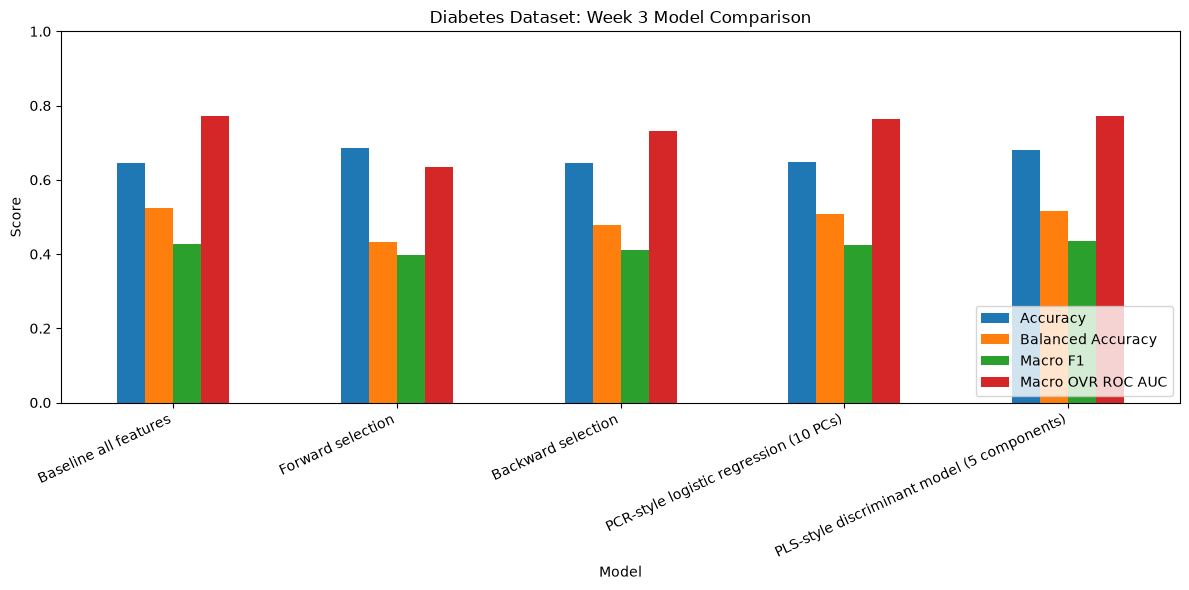

In [18]:
final_comparison.set_index("Model")[
    ["Accuracy", "Balanced Accuracy", "Macro F1", "Macro OVR ROC AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Diabetes Dataset: Week 3 Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

- The final model comparison plot shows that **no single model dominates every metric.:
    - The PLS-style model has the highest macro F1. 
    - The all-features logistic regression has the strongest balanced accuracy and ROC AUC. Forward selection has higher accuracy than the baseline but weaker balanced performance, which suggests that it is less useful for the minority classes.

- For this diabetes dataset, the dimension-reduction methods were competitive with the full model, while stepwise feature selection did not improve overall performance.

#### [Dataset 1] | *18- Classification report for best macro F1 model*

In [19]:
print(classification_report(
    y_test,
    pls_predictions,
    digits=3,
    zero_division=0
))

pls_confusion = pd.DataFrame(
    confusion_matrix(y_test, pls_predictions),
    index=["Actual 0", "Actual 1", "Actual 2"],
    columns=["Predicted 0", "Predicted 1", "Predicted 2"]
)

display(pls_confusion)

              precision    recall  f1-score   support

           0      0.943     0.702     0.805     42741
           1      0.034     0.234     0.060       926
           2      0.341     0.609     0.437      7069

    accuracy                          0.681     50736
   macro avg      0.440     0.515     0.434     50736
weighted avg      0.843     0.681     0.740     50736



,Predicted 0,Predicted 1,Predicted 2
Actual 0,30014,4846,7881
Actual 1,292,217,417
Actual 2,1512,1255,4302


- The best macro F1 model was the **PLS-style discriminant model with 5 components**.

- The executed classification report was:

| Class | Precision | Recall | F1-score | Support |
|---:|---:|---:|---:|---:|
| 0 | 0.943 | 0.702 | 0.805 | 42,741 |
| 1 | 0.034 | 0.234 | 0.060 | 926 |
| 2 | 0.341 | 0.609 | 0.437 | 7,069 |

- Overall metrics:

| Metric | Value |
|---|---:|
| Accuracy | 0.681 |
| Macro F1 | 0.434 |
| Weighted F1 | 0.740 |

- The executed confusion matrix was:

|  | Predicted 0 | Predicted 1 | Predicted 2 |
|---|---:|---:|---:|
| Actual 0 | 30,014 | 4,846 | 7,881 |
| Actual 1 | 292 | 217 | 417 |
| Actual 2 | 1,512 | 1,255 | 4,302 |

- The model correctly identified 4,302 out of 7,069 diabetes cases and 217 out of 926 prediabetes cases. 
    - However, class 1 remains very difficult to detect because it is extremely rare and overlaps with the other two classes.

    - This result shows why accuracy is not enough. The model has moderate accuracy, but its class 1 precision is very low. 
    - For a health classification problem, additional imbalance-handling strategies would be needed if detecting prediabetes is a priority.

#### [Dataset 1] | *19- Summary*

- **Forward and backward selection** produced smaller feature sets, but they did not outperform the full model. 

- **PCR** reduced the feature space to 10 principal components and performed close to the full model. 

- The **PLS-style** model used only 5 components and achieved the best macro F1.

- The main takeaway is that **feature selection and dimension reduction can simplify a model, but they do not always improve every performance metric**. 

- For this dataset, PLS-style dimensionality reduction was the **strongest** Week 3 approach by macro F1, while the **full logistic regression model** remained strongest by balanced accuracy and ROC AUC.

## Dataset 2: Obesity Levels

#### [Dataset 2] | *1- Load preprocessed obesity dataset*

In [20]:
obesity_path = "obesity_preprocessed_wk1.csv"


df_obesity_model = pd.read_csv(obesity_path)

print("Dataset shape:", df_obesity_model.shape)
display(df_obesity_model.head())

target = "NObeyesdad"

class_counts = df_obesity_model[target].value_counts()
display(class_counts.to_frame("Class Count"))

Dataset shape: (2111, 24)


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,family_history_with_overweight_yes,...,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,NObeyesdad
0,21.0,1.62,64.0,2.0,3.0,2.0,0.0,1.0,0,1,...,0,0,0,0,1,0,0,1,0,Normal_Weight
1,21.0,1.52,56.0,3.0,3.0,3.0,3.0,0.0,0,1,...,1,1,0,1,0,0,0,1,0,Normal_Weight
2,23.0,1.80,77.0,2.0,3.0,2.0,2.0,1.0,1,1,...,0,0,1,0,0,0,0,1,0,Normal_Weight
3,27.0,1.80,87.0,3.0,3.0,2.0,2.0,0.0,1,0,...,0,0,1,0,0,0,0,0,1,Overweight_Level_I
4,22.0,1.78,89.8,2.0,1.0,2.0,0.0,0.0,1,0,...,0,0,0,1,0,0,0,1,0,Overweight_Level_II


,Class Count
NObeyesdad,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_I,290
Overweight_Level_II,290
Normal_Weight,287
Insufficient_Weight,272


- The executed dataset shape was:

| Rows | Columns |
|---:|---:|
| 2,111 | 24 |


- There are **23** predictor columns and one target column, `NObeyesdad`.

- The target class distribution was:

| Class | Count |
|---|---:|
| Obesity_Type_I | 351 |
| Obesity_Type_III | 324 |
| Obesity_Type_II | 297 |
| Overweight_Level_I | 290 |
| Overweight_Level_II | 290 |
| Normal_Weight | 287 |
| Insufficient_Weight | 272 |

- The classes are **fairly balanced** compared with the diabetes dataset, so accuracy is more meaningful here. However, macro F1 and balanced accuracy are still useful because this is a multiclass classification problem.

#### [Dataset 2] | *2- Train-test split*

In [21]:
X = df_obesity_model.drop(columns=[target])
y = df_obesity_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

display(y_train.value_counts().to_frame("Train Class Count"))
display(y_test.value_counts().to_frame("Test Class Count"))

Training shape: (1688, 23)
Testing shape: (423, 23)


,Train Class Count
NObeyesdad,
Obesity_Type_I,281
Obesity_Type_III,259
Obesity_Type_II,237
Overweight_Level_I,232
Overweight_Level_II,232
Normal_Weight,229
Insufficient_Weight,218


,Test Class Count
NObeyesdad,
Obesity_Type_I,70
Obesity_Type_III,65
Obesity_Type_II,60
Normal_Weight,58
Overweight_Level_II,58
Overweight_Level_I,58
Insufficient_Weight,54


- The data was split into **training and testing** sets using **stratification**

- The split was:

| Split | Shape |
|---|---:|
| Training | (1,688, 23) |
| Testing | (423, 23) |

- **Stratification** keeps the obesity-class **proportions similar** in both the training and test sets. This matters because the model should be evaluated fairly across all seven obesity categories.

#### [Dataset 2] | *3- Create selection training and validation sets*

In [22]:
X_sel_train, X_sel_valid, y_sel_train, y_sel_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.30,
    random_state=42,
    stratify=y_train
)

print("Selection training shape:", X_sel_train.shape)
print("Selection validation shape:", X_sel_valid.shape)

display(y_sel_train.value_counts().to_frame("Selection Train Count"))

Selection training shape: (1181, 23)
Selection validation shape: (507, 23)


,Selection Train Count
NObeyesdad,
Obesity_Type_I,197
Obesity_Type_III,181
Obesity_Type_II,166
Overweight_Level_II,162
Overweight_Level_I,162
Normal_Weight,160
Insufficient_Weight,153


- The **training set** was further split into a **selection-training set** and a **selection-validation set**

- The split was:

| Split | Shape |
|---|---:|
| Selection training | (1,181, 23) |
| Selection validation | (507, 23) |

- These sets are used only for **forward and backward feature selection**

- A**fter features are selected**, the final models are trained on the **full training set** and evaluated on the **held-out test set**

#### [Dataset 2] | *4- Forward and backward selection functions*

In [23]:
fast_selection_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(
            max_iter=300,
            tol=0.01,
            class_weight="balanced",
            solver="lbfgs"
        ))
    ]
)

def score_feature_set(features):
    fast_selection_model.fit(X_sel_train[features], y_sel_train)
    predictions = fast_selection_model.predict(X_sel_valid[features])
    
    return f1_score(
        y_sel_valid,
        predictions,
        average="macro"
    )


def forward_selection(feature_names, number_of_features=8):
    selected_features = []
    remaining_features = list(feature_names)
    steps = []
    
    for step in range(number_of_features):
        best_feature = None
        best_score = -1
        
        for feature in remaining_features:
            candidate_features = selected_features + [feature]
            score = score_feature_set(candidate_features)
            
            if score > best_score:
                best_score = score
                best_feature = feature
        
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        
        steps.append({
            "Step": step + 1,
            "Added Feature": best_feature,
            "Validation Macro F1": best_score
        })
    
    return selected_features, pd.DataFrame(steps)


def backward_selection(feature_names, number_of_features=8):
    current_features = list(feature_names)
    steps = []
    
    while len(current_features) > number_of_features:
        best_feature_to_remove = None
        best_score = -1
        best_remaining_features = None
        
        for feature in current_features:
            candidate_features = [
                item for item in current_features
                if item != feature
            ]
            
            score = score_feature_set(candidate_features)
            
            if score > best_score:
                best_score = score
                best_feature_to_remove = feature
                best_remaining_features = candidate_features
        
        current_features = best_remaining_features
        
        steps.append({
            "Step": len(steps) + 1,
            "Removed Feature": best_feature_to_remove,
            "Validation Macro F1": best_score,
            "Remaining Feature Count": len(current_features)
        })
    
    return current_features, pd.DataFrame(steps)

- We have defined the **forward and backward selection logic**:

    - **Forward selection** starts with no predictors and adds the feature that improves **validation macro F1** the most at each step

    - **Backward selection** starts with all predictors and removes the feature whose removal gives the **best validation macro F1** at each step.

    - **Macro F1** is used because it treats **all obesity classes equally**

#### [Dataset 2] | *5- Run forward selection*

In [24]:
all_features = X.columns.tolist()

forward_features, forward_steps = forward_selection(
    feature_names=all_features,
    number_of_features=8
)

display(forward_steps)

print("Selected forward features:")
print(forward_features)

,Step,Added Feature,Validation Macro F1
0,1,Weight,0.460174
1,2,Height,0.867762
2,3,CAEC_no,0.885935
3,4,FCVC,0.883995
4,5,TUE,0.900150
5,6,MTRANS_Motorbike,0.890060
6,7,SCC_yes,0.887875
7,8,CAEC_Frequently,0.895265


Selected forward features:
['Weight', 'Height', 'CAEC_no', 'FCVC', 'TUE', 'MTRANS_Motorbike', 'SCC_yes', 'CAEC_Frequently']


- The strongest jump happened after **adding Height to Weight**, which makes sense because **obesity categor**y is strongly related to the combination of weight and height 

- The best validation **macro F1** occurred at **step 5**, but we keep 8 features to maintain a fixed feature-count comparison

#### [Dataset 2] | *6- Run backward selection*

In [25]:
backward_features, backward_steps = backward_selection(
    feature_names=all_features,
    number_of_features=8
)

display(backward_steps)

print("Selected backward features:")
print(backward_features)

,Step,Removed Feature,Validation Macro F1,Remaining Feature Count
0,1,CAEC_Sometimes,0.835916,22
1,2,MTRANS_Motorbike,0.845188,21
2,3,Age,0.853434,20
3,4,MTRANS_Walking,0.859929,19
4,5,CALC_Frequently,0.865946,18
5,6,CAEC_Frequently,0.864108,17
6,7,MTRANS_Bike,0.869967,16
7,8,CALC_no,0.876248,15
8,9,SMOKE_yes,0.873720,14
9,10,NCP,0.867927,13


Selected backward features:
['Height', 'Weight', 'FAF', 'Gender_Male', 'family_history_with_overweight_yes', 'FAVC_yes', 'SCC_yes', 'MTRANS_Public_Transportation']


- **Backward selection** chose a **different** feature set from **forward selection**
    - **Stepwise methods** do not search every possible feature combination, so the **order of adding or removing variables can affect the final model**

#### [Dataset 2] | *7- Evaluate all-features, forward-selection, and backward-selection models*

In [26]:
final_logistic_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="lbfgs"
        ))
    ]
)

def evaluate_multiclass_model(model_name, model, X_train_data, X_test_data):
    model.fit(X_train_data, y_train)
    
    predictions = model.predict(X_test_data)
    probabilities = model.predict_proba(X_test_data)
    
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_test, predictions),
        "Macro F1": f1_score(y_test, predictions, average="macro"),
        "Weighted F1": f1_score(y_test, predictions, average="weighted"),
        "Macro OVR ROC AUC": roc_auc_score(
            y_test,
            probabilities,
            multi_class="ovr",
            average="macro"
        )
    }, predictions


selection_metrics = []
selection_predictions = {}

for model_name, feature_set in [
    ("Baseline all features", all_features),
    ("Forward selection", forward_features),
    ("Backward selection", backward_features)
]:
    metrics, predictions = evaluate_multiclass_model(
        model_name=model_name,
        model=final_logistic_model,
        X_train_data=X_train[feature_set],
        X_test_data=X_test[feature_set]
    )
    
    selection_metrics.append(metrics)
    selection_predictions[model_name] = predictions

selection_metrics_df = pd.DataFrame(selection_metrics)

display(selection_metrics_df)

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro OVR ROC AUC
0,Baseline all features,0.862884,0.861032,0.858929,0.861380,0.980325
1,Forward selection,0.907801,0.907811,0.905798,0.906533,0.988822
2,Backward selection,0.898345,0.897732,0.896175,0.897794,0.986861


- The executed model comparison was:

| Model | Accuracy | Balanced Accuracy | Macro F1 | Weighted F1 | Macro OVR ROC AUC |
|---|---:|---:|---:|---:|---:|
|**Baseline all features** | 0.862884 | 0.861032 | 0.858929 | 0.861380 | 0.980325 |
| **Forward selection** | 0.907801 | 0.907811 | 0.905798 | 0.906533 | 0.988822 |
| **Backward selection** | 0.898345 | 0.897732 | 0.896175 | 0.897794 | 0.986861 |

- **Forward selection** performed best across all listed metrics
    - This means the reduced **8-feature model** actually **outperformed** the model using all 23 predictors

- **Backward selection** also improved over the all-features baseline, but it did not perform as well as forward selection.

- For this obesity dataset, **feature selection was very helpful** because the strongest features, especially `Weight` and `Height`, captured much of the signal needed to distinguish obesity categories.

#### [Dataset 2] | *8- Visualize stepwise model comparison*

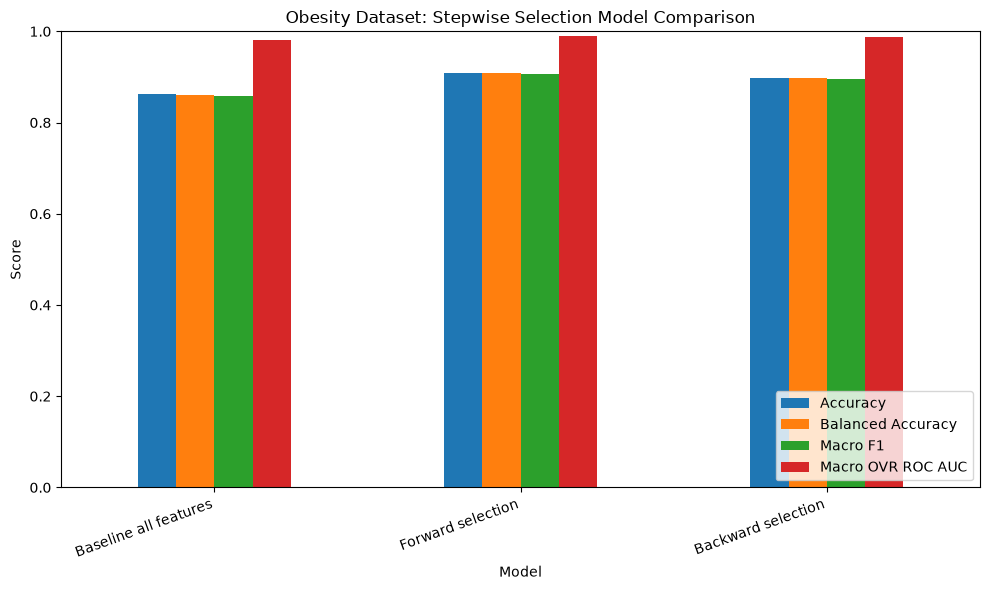

In [27]:
selection_metrics_df.set_index("Model")[
    ["Accuracy", "Balanced Accuracy", "Macro F1", "Macro OVR ROC AUC"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Obesity Dataset: Stepwise Selection Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

- The plot shows that **forward selection** had the **strongest performance** among the stepwise-selection models

- The selected forward model used only **8 predictors** but outperformed the full 23-feature model

- This is a good example of why feature selection can be useful: **removing weaker or noisy predictors can improve generalization**

#### [Dataset 2] | *9- Tune PCR-style model*

In [28]:
component_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

pcr_results = []

for n_components in [2, 5, 10, 15, 20, 23]:
    pcr_model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("pca", PCA(
                n_components=n_components,
                random_state=42
            )),
            ("logit", LogisticRegression(
                max_iter=1000,
                tol=0.01,
                class_weight="balanced",
                solver="lbfgs"
            ))
        ]
    )
    
    scores = cross_val_score(
        pcr_model,
        X_train,
        y_train,
        cv=component_cv,
        scoring="f1_macro"
    )
    
    pcr_results.append({
        "n_components": n_components,
        "Mean CV Macro F1": scores.mean(),
        "Std CV Macro F1": scores.std()
    })

pcr_results_df = pd.DataFrame(pcr_results)

display(pcr_results_df)

,n_components,Mean CV Macro F1,Std CV Macro F1
0,2,0.446441,0.005622
1,5,0.528869,0.004896
2,10,0.549069,0.009943
3,15,0.601838,0.009923
4,20,0.706069,0.020674
5,23,0.837141,0.003798


- The **PCR-style** model was tuned using **PCA components followed by logistic regression**

- The executed cross-validation results were:

| n_components | Mean CV Macro F1 | Std CV Macro F1 |
|---:|---:|---:|
| 2 | 0.446441 | 0.005622 |
| 5 | 0.528869 | 0.004896 |
| 10 | 0.549069 | 0.009943 |
| 15 | 0.601838 | 0.009923 |
| 20 | 0.706069 | 0.020674 |
| 23 | 0.837141 | 0.003798 |

- The best **PCR-style** setting used all **23 principal components**

- This is important because **PCR** only gives a different model when some components are removed. Since the best result used all components, **PCR** did not provide useful dimensionality reduction for this dataset.

#### [Dataset 2] | *10- Fit and evaluate best PCR-style model*

In [29]:
best_pcr_components = int(
    pcr_results_df.loc[
        pcr_results_df["Mean CV Macro F1"].idxmax(),
        "n_components"
    ]
)

best_pcr_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("pca", PCA(
            n_components=best_pcr_components,
            random_state=42
        )),
        ("logit", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="lbfgs"
        ))
    ]
)

pcr_metrics, pcr_predictions = evaluate_multiclass_model(
    model_name=f"PCR-style logistic regression ({best_pcr_components} PCs)",
    model=best_pcr_model,
    X_train_data=X_train,
    X_test_data=X_test
)

best_pcr_model.fit(X_train, y_train)

explained_variance = (
    best_pcr_model
    .named_steps["pca"]
    .explained_variance_ratio_
)

display(pd.DataFrame([pcr_metrics]))

print("Explained variance ratio:")
print(explained_variance)

print("Total explained variance:")
print(explained_variance.sum())

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro OVR ROC AUC
0,PCR-style logistic regression (23 PCs),0.862884,0.861032,0.858929,0.86138,0.980325


Explained variance ratio:
[1.38143850e-01 9.03375428e-02 8.25610520e-02 7.36804241e-02
 6.04105433e-02 5.65508463e-02 5.53118653e-02 5.02138890e-02
 4.63125676e-02 4.39512641e-02 3.98124930e-02 3.84493572e-02
 3.46772883e-02 3.42851661e-02 3.31106133e-02 2.95396465e-02
 2.62512956e-02 2.49935081e-02 1.64061106e-02 1.24316956e-02
 8.65980697e-03 3.85608968e-03 5.30850052e-05]
Total explained variance:
1.0


- The best **PCR-style** model used **23 principal components**

- The executed test performance was:

| Model | Accuracy | Balanced Accuracy | Macro F1 | Weighted F1 | Macro OVR ROC AUC |
|---|---:|---:|---:|---:|---:|
| **PCR-style logistic regression (23 PCs)** | 0.862884 | 0.861032 | 0.858929 | 0.861380 | 0.980325 |

- The **23** principal components explained **100%** of the **variance** because all components were retained

- This result is nearly identical to the all-features logistic regression model:
    - That is expected because using **all principal components** preserves all the **original feature information**
    - **PCR** only changes performance when lower-variance components are removed

#### [Dataset 2] | *11- Visualize PCA explained variance*

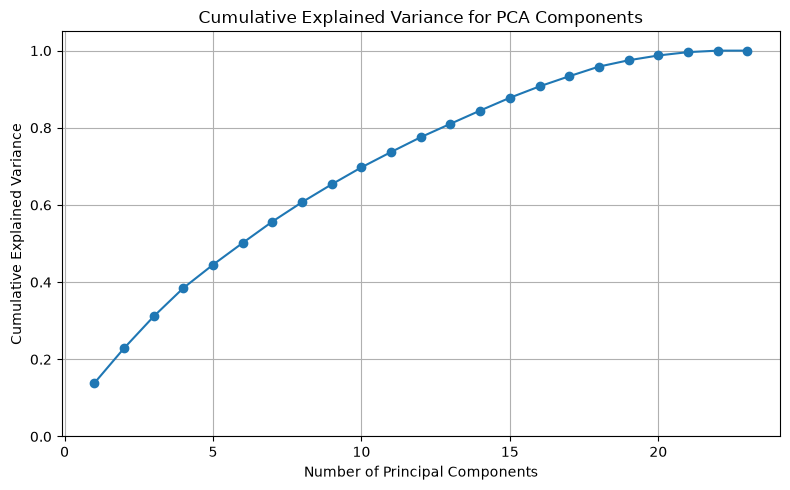

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, best_pcr_components + 1),
    explained_variance.cumsum(),
    marker="o"
)

plt.title("Cumulative Explained Variance for PCA Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.ylim(0, 1.05)
plt.grid(True)
plt.tight_layout()
plt.show()

- The **cumulative explained variance plot** shows how much predictor variance is retained as more principal components are added

- For this dataset, performance improved as more components were included

    - The best **PCR-style** model kept all 23 components, so PCA did not reduce dimensionality in a useful way.

- This also illustrates a **limitation of PCR**: the components are selected based on **variance in the predictors**, not directly based on **usefulness for predicting the target**

#### [Dataset 2] | *12- Define PLS-style discriminant classifier*

In [31]:
class PLSDAClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, n_components=2):
        self.n_components = n_components
    
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        class_to_index = {
            label: index
            for index, label in enumerate(self.classes_)
        }
        
        y_array = np.asarray(y)
        Y = np.zeros((len(y_array), len(self.classes_)))
        
        for row_index, label in enumerate(y_array):
            Y[row_index, class_to_index[label]] = 1
        
        self.model_ = PLSRegression(
            n_components=self.n_components,
            scale=False,
            max_iter=500,
            tol=1e-6
        )
        
        self.model_.fit(X, Y)
        
        return self
    
    def predict(self, X):
        scores = np.asarray(self.model_.predict(X))
        predicted_indexes = np.argmax(scores, axis=1)
        
        return self.classes_[predicted_indexes]
    
    def predict_proba(self, X):
        scores = np.asarray(self.model_.predict(X))
        scores = scores - scores.max(axis=1, keepdims=True)
        
        exp_scores = np.exp(scores)
        probabilities = exp_scores / exp_scores.sum(axis=1, keepdims=True)
        
        return probabilities

- We are defining a **PLS-style** discriminant classifier:

    - **PLSR** is originally designed for **regression**. Since the **obesity target is categorical**, the **target is converted into a one-hot encoded matrix**
    - The model then predicts **class scores**, and the **class with the largest predicted score is selected**

    - This **adapts the PLSR idea to classification**. 

- Unlike **PCA**, **PLS** uses the **relationship between the predictors** and the **target** when constructing components

#### [Dataset 2] | *13- Tune PLS-style model*

In [32]:
pls_results = []

for n_components in [2, 5, 10, 15, 20]:
    pls_model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("plsda", PLSDAClassifier(
                n_components=n_components
            ))
        ]
    )
    
    scores = cross_val_score(
        pls_model,
        X_train,
        y_train,
        cv=component_cv,
        scoring="f1_macro"
    )
    
    pls_results.append({
        "n_components": n_components,
        "Mean CV Macro F1": scores.mean(),
        "Std CV Macro F1": scores.std()
    })

pls_results_df = pd.DataFrame(pls_results)

display(pls_results_df)

,n_components,Mean CV Macro F1,Std CV Macro F1
0,2,0.337928,0.014673
1,5,0.486941,0.017162
2,10,0.583753,0.025056
3,15,0.610284,0.014426
4,20,0.609598,0.026016


- The **PLS-style** model was **tuned** using the **training data**

- The executed cross-validation results were:

| n_components | Mean CV Macro F1 | Std CV Macro F1 |
|---:|---:|---:|
| 2 | 0.337928 | 0.014673 |
| 5 | 0.486941 | 0.017162 |
| 10 | 0.583753 | 0.025056 |
| 15 | 0.610284 | 0.014426 |
| 20 | 0.609598 | 0.026016 |

- The best number of components was **15**, with a mean cross-validation **macro F1** of **0.610284**

- **PLS** improved as more components were added up to **15**, but it still performed below the logistic-regression models
    - This suggests that reducing the obesity data into **PLS components lost some information needed to separate the seven classes**.

#### [Dataset 2] | *14- Fit and evaluate best PLS-style model*

In [33]:
best_pls_components = int(
    pls_results_df.loc[
        pls_results_df["Mean CV Macro F1"].idxmax(),
        "n_components"
    ]
)

best_pls_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("plsda", PLSDAClassifier(
            n_components=best_pls_components
        ))
    ]
)

best_pls_model.fit(X_train, y_train)

pls_predictions = best_pls_model.predict(X_test)
pls_probabilities = best_pls_model.predict_proba(X_test)

pls_metrics = {
    "Model": f"PLS-style discriminant model ({best_pls_components} components)",
    "Accuracy": accuracy_score(y_test, pls_predictions),
    "Balanced Accuracy": balanced_accuracy_score(y_test, pls_predictions),
    "Macro F1": f1_score(y_test, pls_predictions, average="macro"),
    "Weighted F1": f1_score(y_test, pls_predictions, average="weighted"),
    "Macro OVR ROC AUC": roc_auc_score(
        y_test,
        pls_probabilities,
        multi_class="ovr",
        average="macro"
    )
}

display(pd.DataFrame([pls_metrics]))

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro OVR ROC AUC
0,PLS-style discriminant model (15 components),0.64539,0.64231,0.61192,0.614822,0.897057


- The best **PLS-style** model used **15 components**

- The executed t**est performance** was:

| Model | Accuracy | Balanced Accuracy | Macro F1 | Weighted F1 | Macro OVR ROC AUC |
|---|---:|---:|---:|---:|---:|
| **PLS-style discriminant model (15 components)** | 0.645390 | 0.642310 | 0.611920 | 0.614822 | 0.897057 |


- The **PLS-style model** performed substantially worse than the forward-selection, backward-selection, and full-feature logistic regression models

- This means that although **PLS** uses the relationship between **features and the target**, the component representation was not strong enough for this **seven-class obesity problem**

#### [Dataset 2] | *15- Final model comparison*

In [34]:
final_comparison = pd.concat([
    selection_metrics_df,
    pd.DataFrame([pcr_metrics]),
    pd.DataFrame([pls_metrics])
], ignore_index=True)

display(final_comparison)

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro OVR ROC AUC
0,Baseline all features,0.862884,0.861032,0.858929,0.861380,0.980325
1,Forward selection,0.907801,0.907811,0.905798,0.906533,0.988822
2,Backward selection,0.898345,0.897732,0.896175,0.897794,0.986861
3,PCR-style logistic regression (23 PCs),0.862884,0.861032,0.858929,0.861380,0.980325
4,PLS-style discriminant model (15 components),0.645390,0.642310,0.611920,0.614822,0.897057


- The **final executed comparison** is:

| Model | Accuracy | Balanced Accuracy | Macro F1 | Weighted F1 | Macro OVR ROC AUC |
|---|---:|---:|---:|---:|---:|
| **Baseline all features** | 0.862884 | 0.861032 | 0.858929 | 0.861380 | 0.980325 |
| **Forward selection** | 0.907801 | 0.907811 | 0.905798 | 0.906533 | 0.988822 |
| **Backward selection** | 0.898345 | 0.897732 | 0.896175 | 0.897794 | 0.986861 |
| **PCR-style logistic regression (23 PCs)** | 0.862884 | 0.861032 | 0.858929 | 0.861380 | 0.980325 |
| **PLS-style discriminant model (15 components)** | 0.645390 | 0.642310 | 0.611920 | 0.614822 | 0.897057 |

- The **best** model was **forward selection**, with a m**acro F1 of 0.905798**

- This is a **strong result** because the **forward-selection model** used only **8 predictors** but **outperformed** the full **23-feature model**. 

- In this dataset, **stepwise feature selection** was more effective than **PCR** or **PLS-style** dimensionality reduction

#### [Dataset 2] | *16- Visualize final comparison*

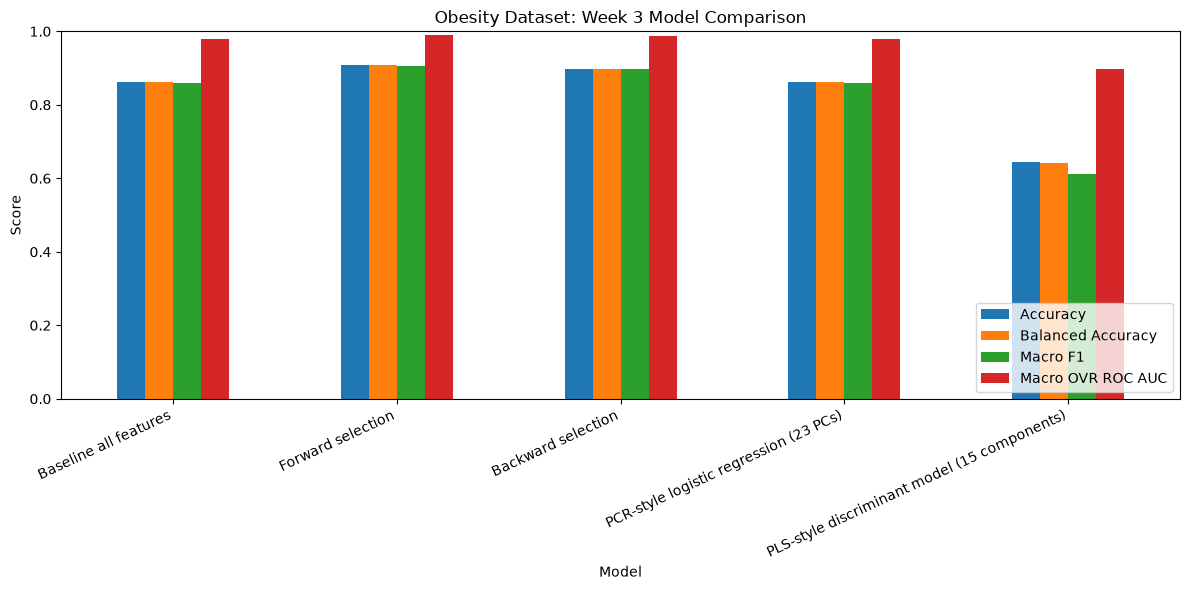

In [35]:
final_comparison.set_index("Model")[
    ["Accuracy", "Balanced Accuracy", "Macro F1", "Macro OVR ROC AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Obesity Dataset: Week 3 Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

- The final comparison plot shows that **forward selection** performs best across the main metrics

- **Backward selection** is also strong, but it does not outperform forward selection. 

- **PCR** with all components performs the same as the baseline because it keeps all feature information. 

- The **PLS-style** model performs the weakest.

- For the **obesity** dataset, **feature selection is more useful than dimensionality reduction**

#### [Dataset 2] | *17- Classification report for the best model*

In [36]:
best_predictions = selection_predictions["Forward selection"]

print(classification_report(
    y_test,
    best_predictions,
    digits=3,
    zero_division=0
))

forward_confusion = pd.DataFrame(
    confusion_matrix(
        y_test,
        best_predictions,
        labels=sorted(y_test.unique())
    ),
    index=[f"Actual {label}" for label in sorted(y_test.unique())],
    columns=[f"Predicted {label}" for label in sorted(y_test.unique())]
)

display(forward_confusion)

                     precision    recall  f1-score   support

Insufficient_Weight      0.915     1.000     0.956        54
      Normal_Weight      0.904     0.810     0.855        58
     Obesity_Type_I      0.939     0.886     0.912        70
    Obesity_Type_II      0.900     0.900     0.900        60
   Obesity_Type_III      0.942     1.000     0.970        65
 Overweight_Level_I      0.870     0.810     0.839        58
Overweight_Level_II      0.873     0.948     0.909        58

           accuracy                          0.908       423
          macro avg      0.906     0.908     0.906       423
       weighted avg      0.908     0.908     0.907       423



,Predicted Insufficient_Weight,Predicted Normal_Weight,Predicted Obesity_Type_I,Predicted Obesity_Type_II,Predicted Obesity_Type_III,Predicted Overweight_Level_I,Predicted Overweight_Level_II
Actual Insufficient_Weight,54,0,0,0,0,0,0
Actual Normal_Weight,5,47,0,0,0,6,0
Actual Obesity_Type_I,0,0,62,6,0,0,2
Actual Obesity_Type_II,0,0,2,54,4,0,0
Actual Obesity_Type_III,0,0,0,0,65,0,0
Actual Overweight_Level_I,0,5,0,0,0,47,6
Actual Overweight_Level_II,0,0,2,0,0,1,55


- The best model was the **forward-selection logistic regression model**

- The model performed especially well on `Insufficient_Weight` and `Obesity_Type_III`, both with recall of 1.000. 

- Most errors occurred between neighboring classes, such as `Normal_Weight` and `Overweight_Level_I`, or `Obesity_Type_I` and `Obesity_Type_II`.

- This is expected because adjacent obesity categories are naturally harder to separate than extreme categories.

#### [Dataset 2] | *18- Summary*

- **Forward selection** was the strongest method. It selected only 8 predictors and achieved the best test performance, with macro F1 of **0.905798**

- **Backward selection** also improved over the full model, but not as much as forward selection

- **PCR** did not help because the best PCR-style model used **all 23 component**s, meaning there was no real dimensionality reduction

- The **PLS-style model** reduced the feature space but performed worse than the logistic-regression models

- The main takeaway is that, for this dataset, **selecting a smaller set of strong predictors was more effective than transforming the predictors into lower-dimensional components**

## Dataset 3: Cervical Cancer

#### [Dataset 3] | *1- Load preprocessed cervical cancer dataset*

In [37]:
cervical_path = "cervical_cancer_preprocessed_wk1.csv"


df_cervical_model = pd.read_csv(cervical_path)

print("Dataset shape:", df_cervical_model.shape)
display(df_cervical_model.head())

target = "Biopsy"

class_counts = df_cervical_model[target].value_counts().sort_index()
display(class_counts.to_frame("Class Count"))

Dataset shape: (858, 62)


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs:pelvic inflammatory disease_missing,STDs:genital herpes_missing,STDs:molluscum contagiosum_missing,STDs:AIDS_missing,STDs:HIV_missing,STDs:Hepatitis B_missing,STDs:HPV_missing,STDs: Time since first diagnosis_missing,STDs: Time since last diagnosis_missing,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,1,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,1,0
2,34,1.0,17.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,1,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,0,0,0,0,0,0,0,1,1,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,0,0,0,0,0,0,0,1,1,0


,Class Count
Biopsy,
0,803
1,55


- This is a **highly imbalanced binary classification problem**
    - Only **55** observations are biopsy-positive
    - Therefore, accuracy alone is not enough. Balanced accuracy, recall, F1, ROC AUC, and average precision are more useful for evaluating model performance

#### [Dataset 3] | *2- Train-test split*

In [38]:
X = df_cervical_model.drop(columns=[target])
y = df_cervical_model[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

display(y_train.value_counts().sort_index().to_frame("Train Class Count"))
display(y_test.value_counts().sort_index().to_frame("Test Class Count"))

Training shape: (686, 61)
Testing shape: (172, 61)


,Train Class Count
Biopsy,
0,642
1,44


,Test Class Count
Biopsy,
0,161
1,11


- The data was **split** into training and testing sets using **stratification**

- The executed split was:

| Split | Shape |
|---|---:|
| Training | (686, 61) |
| Testing | (172, 61) |

- The **training target distribution** was:

| Class | Count |
|---:|---:|
| 0 | 642 |
| 1 | 44 |

- The **testing target distribution** was:

| Class | Count |
|---:|---:|
| 0 | 161 |
| 1 | 11 |

- **Stratification** is important because the **positive biopsy class is rare**
    - It keeps the **minority class represented** in both the training and test sets.

#### [Dataset 3] | *3- Create selection sample*

In [39]:
selection_data = X_train.copy()
selection_data["target"] = y_train.values

positive_cases = selection_data[selection_data["target"] == 1]
negative_cases = selection_data[selection_data["target"] == 0].sample(
    n=220,
    random_state=42
)

selection_sample = (
    pd.concat([positive_cases, negative_cases])
    .sample(frac=1, random_state=42)
)

X_model_select = selection_sample.drop(columns=["target"])
y_model_select = selection_sample["target"].astype(int)

X_sel_train, X_sel_valid, y_sel_train, y_sel_valid = train_test_split(
    X_model_select,
    y_model_select,
    test_size=0.30,
    random_state=42,
    stratify=y_model_select
)

print("Selection sample shape:", X_model_select.shape)
display(y_model_select.value_counts().sort_index().to_frame("Selection Sample Count"))

print("Selection training shape:", X_sel_train.shape)
print("Selection validation shape:", X_sel_valid.shape)

Selection sample shape: (264, 61)


,Selection Sample Count
target,
0,220
1,44


Selection training shape: (184, 61)
Selection validation shape: (80, 61)


- A **smaller selection sample** was created for **forward and backward selection**

- The executed selection sample had:

| Class | Count |
|---:|---:|
| 0 | 220 |
| 1 | 44 |

- The selection split was:

| Split | Shape |
|---|---:|
| **Selection training** | (184, 61) |
| **Selection validation** | (80, 61) |

- This **sample is used only for feature selection**

- **After selecting features**, the **final models** are trained on the **full training set** and evaluated on the **held-out test set**

#### [Dataset 3] | *4- Forward and backward selection functions*

In [40]:
fast_selection_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(
            max_iter=300,
            tol=0.01,
            class_weight="balanced",
            solver="liblinear",
            random_state=42
        ))
    ]
)


def score_feature_set(features):
    fast_selection_model.fit(X_sel_train[features], y_sel_train)
    predictions = fast_selection_model.predict(X_sel_valid[features])
    
    return f1_score(
        y_sel_valid,
        predictions,
        zero_division=0
    )


def forward_selection(feature_names, number_of_features=8):
    selected_features = []
    remaining_features = list(feature_names)
    steps = []
    
    for step in range(number_of_features):
        feature_scores = []
        
        for feature in remaining_features:
            candidate_features = selected_features + [feature]
            score = score_feature_set(candidate_features)
            feature_scores.append((score, feature))
        
        feature_scores.sort(reverse=True)
        best_score, best_feature = feature_scores[0]
        
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        
        steps.append({
            "Step": step + 1,
            "Added Feature": best_feature,
            "Validation F1": best_score
        })
    
    return selected_features, pd.DataFrame(steps)


def coefficient_backward_selection(feature_names, number_of_features=8):
    current_features = list(feature_names)
    steps = []
    
    while len(current_features) > number_of_features:
        fast_selection_model.fit(X_sel_train[current_features], y_sel_train)
        
        coefficient_values = np.abs(
            fast_selection_model
            .named_steps["logit"]
            .coef_[0]
        )
        
        remove_index = int(np.argmin(coefficient_values))
        removed_feature = current_features[remove_index]
        
        current_features = [
            feature for feature in current_features
            if feature != removed_feature
        ]
        
        validation_score = score_feature_set(current_features)
        
        steps.append({
            "Step": len(steps) + 1,
            "Removed Feature": removed_feature,
            "Validation F1": validation_score,
            "Remaining Feature Count": len(current_features)
        })
    
    return current_features, pd.DataFrame(steps)

- In the cell above, we have defined the **forward and backward selection logic**:

    - **Forward selection** starts with no predictors and adds the feature that improves **validation F1** the most

    - **Backward selection** starts with all predictors and removes the feature with the smallest absolute standardized coefficient at each step 
        - This is a **practical version of backward elimination** for this dataset because the preprocessed cervical cancer file has **61 predictors**

    - **F1** is used as the selection criterion because this is an **imbalanced binary classification task** and the positive biopsy class is rare

#### [Dataset 3] | *5- Run forward selection*

In [41]:
all_features = X.columns.tolist()

forward_features, forward_steps = forward_selection(
    feature_names=all_features,
    number_of_features=8
)

display(forward_steps)

print("Selected forward features:")
print(forward_features)

,Step,Added Feature,Validation F1
0,1,Schiller,0.866667
1,2,Smokes_missing,0.866667
2,3,Smokes (years)_missing,0.866667
3,4,Smokes (years),0.866667
4,5,Smokes (packs/year)_missing,0.866667
5,6,Smokes (packs/year),0.866667
6,7,Smokes,0.866667
7,8,STDs_missing,0.866667


Selected forward features:
['Schiller', 'Smokes_missing', 'Smokes (years)_missing', 'Smokes (years)', 'Smokes (packs/year)_missing', 'Smokes (packs/year)', 'Smokes', 'STDs_missing']


- The first selected feature was **Schiller**, which makes sense because **Schiller** is a **diagnostic-related variable** and is strongly connected to the biopsy result.

- After **Schiller** was selected, the validation **F1 did not improve further**, so the **additional variables did not add much new validation signal in this sample**

#### [Dataset 3] | *6- Run backward selection*

In [42]:
backward_features, backward_steps = coefficient_backward_selection(
    feature_names=all_features,
    number_of_features=8
)

display(backward_steps)

print("Selected backward features:")
print(backward_features)

,Step,Removed Feature,Validation F1,Remaining Feature Count
0,1,STDs:cervical condylomatosis,0.838710,60
1,2,STDs:vaginal condylomatosis,0.838710,59
2,3,STDs:syphilis,0.838710,58
3,4,STDs:pelvic inflammatory disease,0.838710,57
4,5,STDs:genital herpes,0.838710,56
5,6,STDs:molluscum contagiosum,0.838710,55
6,7,STDs:AIDS,0.838710,54
7,8,STDs:Hepatitis B,0.838710,53
8,9,STDs:condylomatosis,0.838710,52
9,10,STDs,0.838710,51


Selected backward features:
['Num of pregnancies', 'IUD (years)', 'Dx:CIN', 'Schiller', 'Hormonal Contraceptives_missing', 'Hormonal Contraceptives (years)_missing', 'STDs:HIV_missing', 'STDs:HPV_missing']


- The selected set includes **Schiller** and **Dx:CIN**, which are **clinically** and **diagnostically** meaningful variables

- It also includes **missingness indicators**, suggesting that **whether a value was missing may carry predictive information** in this dataset

- This result also shows an **important Week 3 point**: 
    - **forward and backward selection** can produce different selected feature sets because they follow different stepwise paths

#### [Dataset 3] | *7- Evaluate all-features, forward-selection, and backward-selection models*

In [49]:
final_logistic_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="liblinear",
            random_state=42
        ))
    ]
)


def evaluate_binary_model(model_name, model, X_train_data, X_test_data):
    model.fit(X_train_data, y_train)
    
    predictions = model.predict(X_test_data)
    probabilities = model.predict_proba(X_test_data)[:, 1]
    
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, probabilities),
        "Average Precision": average_precision_score(y_test, probabilities)
    }, predictions


selection_metrics = []
selection_predictions = {}

for model_name, feature_set in [
    ("Baseline all features", all_features),
    ("Forward selection", forward_features),
    ("Backward selection", backward_features)
]:
    metrics, predictions = evaluate_binary_model(
        model_name=model_name,
        model=final_logistic_model,
        X_train_data=X_train[feature_set],
        X_test_data=X_test[feature_set]
    )
    
    selection_metrics.append(metrics)
    selection_predictions[model_name] = predictions

selection_metrics_df = pd.DataFrame(selection_metrics)

display(selection_metrics_df)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC AUC,Average Precision
0,Baseline all features,0.959302,0.893563,0.642857,0.818182,0.720000,0.936759,0.534424
1,Forward selection,0.965116,0.896669,0.692308,0.818182,0.750000,0.885093,0.604051
2,Backward selection,0.953488,0.890457,0.600000,0.818182,0.692308,0.885658,0.520960


- The executed model comparison was:

| Model | Accuracy | Balanced Accuracy | Precision | Recall | F1 | ROC AUC | Average Precision |
|---|---:|---:|---:|---:|---:|---:|---:|
| **Baseline all features** | 0.959302 | 0.893563 | 0.642857 | 0.818182 | 0.720000 | 0.936759 | 0.534424 |
| **Forward selection** | 0.965116 | 0.896669 | 0.692308 | 0.818182 | 0.750000 | 0.885093 | 0.604051 |
| **Backward selection** | 0.953488 | 0.890457 | 0.600000 | 0.818182 | 0.692308 | 0.885658 | 0.520960 |


- **Forward selection** produced the **best F1 score** among the stepwise-selection models, with **F1 = 0.75**

- The **forward-selection** model also had the **best precision**, while all three models had the same **recall of 0.818182**

    - This means each model found 9 of the 11 biopsy-positive cases, but **forward selection** produced **fewer false positives**

- For this dataset, a small selected feature set performed better than the full feature set on **F1**

#### [Dataset 3] | *8- Visualize stepwise model comparison*

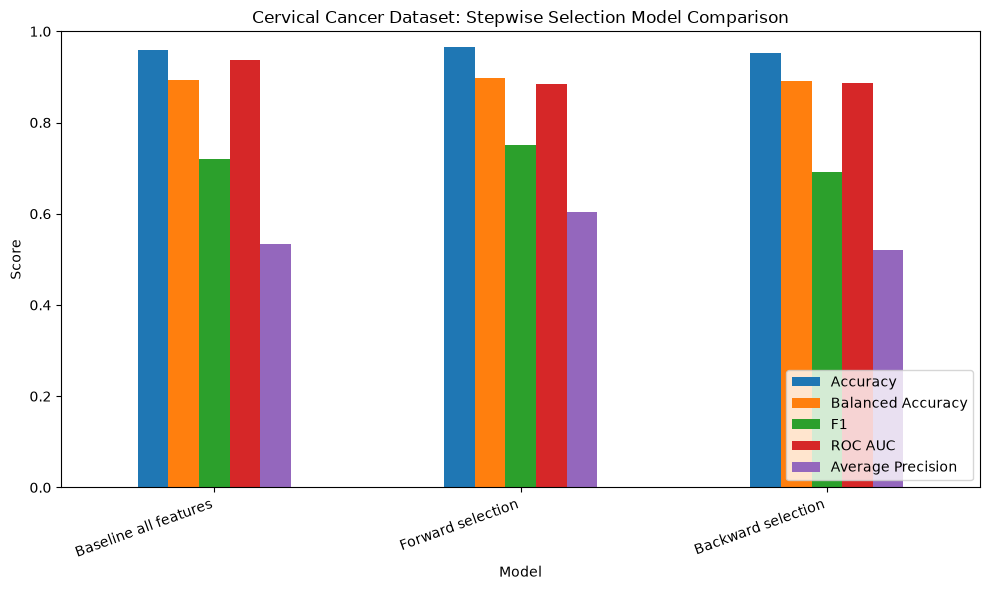

In [50]:
selection_metrics_df.set_index("Model")[
    ["Accuracy", "Balanced Accuracy", "F1", "ROC AUC", "Average Precision"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Cervical Cancer Dataset: Stepwise Selection Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

- The plot compares the **all-features model** with the **forward-selection** and **backward-selection** models:

    - **Forward selection** has the best accuracy, balanced accuracy, F1, and average precision among the stepwise models.
    
    - The **all-features model** has the highest ROC AUC, but its average precision is lower than forward selection

- Because this dataset is **imbalanced**, **F1** and **average precision** are especially **important**

#### [Dataset 3] | *9- Tune PCR-style model*

In [51]:
component_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

pcr_results = []

for n_components in [2, 5, 10, 20, 40, 61]:
    pcr_model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("pca", PCA(
                n_components=n_components,
                random_state=42
            )),
            ("logit", LogisticRegression(
                max_iter=1000,
                tol=0.01,
                class_weight="balanced",
                solver="liblinear",
                random_state=42
            ))
        ]
    )
    
    scores = []
    
    for train_index, valid_index in component_cv.split(X_train, y_train):
        X_cv_train = X_train.iloc[train_index]
        X_cv_valid = X_train.iloc[valid_index]
        y_cv_train = y_train.iloc[train_index]
        y_cv_valid = y_train.iloc[valid_index]
        
        pcr_model.fit(X_cv_train, y_cv_train)
        probabilities = pcr_model.predict_proba(X_cv_valid)[:, 1]
        
        scores.append(
            average_precision_score(y_cv_valid, probabilities)
        )
    
    pcr_results.append({
        "n_components": n_components,
        "Mean CV Average Precision": np.mean(scores),
        "Std CV Average Precision": np.std(scores)
    })

pcr_results_df = pd.DataFrame(pcr_results)

display(pcr_results_df)

,n_components,Mean CV Average Precision,Std CV Average Precision
0,2,0.237684,0.014269
1,5,0.351479,0.077238
2,10,0.562920,0.024733
3,20,0.596666,0.059778
4,40,0.588137,0.083082
5,61,0.588137,0.083082


- The **PCR-style** model was tuned using **PCA components followed by logistic regression**

- The executed **cross-validation results** were:

| n_components | Mean CV Average Precision | Std CV Average Precision |
|---:|---:|---:|
| 2 | 0.237684 | 0.014269 |
| 5 | 0.351479 | 0.077238 |
| 10 | 0.562920 | 0.024733 |
| 20 | 0.596666 | 0.059778 |
| 40 | 0.588137 | 0.083082 |
| 61 | 0.588137 | 0.083082 |

- The **best PCR-style** setting used **20 principal components**

- This shows that keeping only a few principal components was not enough. Performance improved as more components were added up to 20

- However, adding more than 20 components did not improve cross-validated average precision

#### [Dataset 3] | *10- Fit and evaluate best PCR-style model*

In [52]:
best_pcr_components = int(
    pcr_results_df.loc[
        pcr_results_df["Mean CV Average Precision"].idxmax(),
        "n_components"
    ]
)

best_pcr_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("pca", PCA(
            n_components=best_pcr_components,
            random_state=42
        )),
        ("logit", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="liblinear",
            random_state=42
        ))
    ]
)

pcr_metrics, pcr_predictions = evaluate_binary_model(
    model_name=f"PCR-style logistic regression ({best_pcr_components} PCs)",
    model=best_pcr_model,
    X_train_data=X_train,
    X_test_data=X_test
)

best_pcr_model.fit(X_train, y_train)

explained_variance = (
    best_pcr_model
    .named_steps["pca"]
    .explained_variance_ratio_
)

display(pd.DataFrame([pcr_metrics]))

print("Explained variance ratio:")
print(explained_variance)

print("Total explained variance:")
print(explained_variance.sum())

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC AUC,Average Precision
0,PCR-style logistic regression (20 PCs),0.959302,0.893563,0.642857,0.818182,0.72,0.896669,0.705758


Explained variance ratio:
[0.30506201 0.11826571 0.05369393 0.05178841 0.04117063 0.03536747
 0.03351996 0.02880165 0.02662135 0.02436461 0.02380167 0.02202643
 0.01850111 0.01828927 0.01746856 0.01705153 0.01678346 0.01532955
 0.01452869 0.01445743]
Total explained variance:
0.8968934269283284


- The **best PCR-style** model used **20 principal components**

- The executed **test performance** was:

| Model | Accuracy | Balanced Accuracy | Precision | Recall | F1 | ROC AUC | Average Precision |
|---|---:|---:|---:|---:|---:|---:|---:|
| **PCR-style logistic regression (20 PCs)** | 0.959302 | 0.893563 | 0.642857 | 0.818182 | 0.720000 | 0.896669 | 0.705758 |


- The **20 principal components** explained about **89.69%** of the total predictor variance.

- The **average precision** of the PCR-style model was** 0.705758**, which was the highest average precision among all the models tested. 

    - This means the **PCR-style model ranked biopsy-positive cases better** than the other models, even though its **F1** was not the highest.

#### [Dataset 3] | *11- Visualize PCA explained variance*

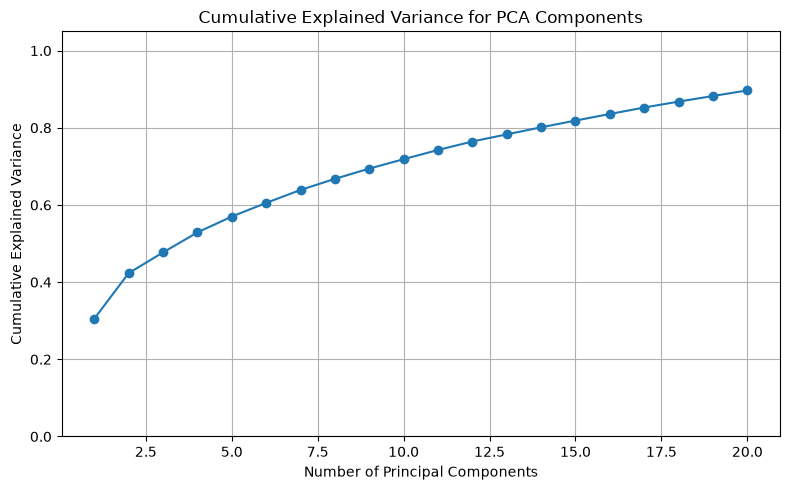

In [53]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, best_pcr_components + 1),
    explained_variance.cumsum(),
    marker="o"
)

plt.title("Cumulative Explained Variance for PCA Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.ylim(0, 1.05)
plt.grid(True)
plt.tight_layout()
plt.show()

- The **cumulative explained variance** plot shows how much predictor variance is **retained as more principal components are added**

- The selected **20** components explain about **89.69%** of the total variance

    - This means **PCR** compressed the **original 61 predictors into 20 transformed components** while still retaining most of the predictor variation

- **Note**:  **PCA** can reduce dimensionality, but the retained components are chosen based on variance in `X`, not directly based on the target

#### [Dataset 3] | *12- Define PLS-style discriminant classifier*

In [54]:
class PLSDAClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, n_components=2):
        self.n_components = n_components
    
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        class_to_index = {
            label: index
            for index, label in enumerate(self.classes_)
        }
        
        y_array = np.asarray(y)
        Y = np.zeros((len(y_array), len(self.classes_)))
        
        for row_index, label in enumerate(y_array):
            Y[row_index, class_to_index[label]] = 1
        
        self.model_ = PLSRegression(
            n_components=self.n_components,
            scale=False,
            max_iter=500,
            tol=1e-6
        )
        
        self.model_.fit(X, Y)
        
        return self
    
    def predict(self, X):
        scores = np.asarray(self.model_.predict(X))
        predicted_indexes = np.argmax(scores, axis=1)
        
        return self.classes_[predicted_indexes]
    
    def predict_proba(self, X):
        scores = np.asarray(self.model_.predict(X))
        scores = scores - scores.max(axis=1, keepdims=True)
        
        exp_scores = np.exp(scores)
        probabilities = exp_scores / exp_scores.sum(axis=1, keepdims=True)
        
        return probabilities

- In the cell above, we introduce a **PLS-style discriminant classifier**

- **PLSR** is originally a **regression method**, so the **binary target** is converted into a two-column one-hot encoded target

    - The model predicts class scores, and the class with the largest score is selected

- Unlike **PCR**, **PLS** uses the relationship between the predictors and the target when creating components

#### [Dataset 3] | *13- Create balanced training sample for PLS-style model*

In [55]:
train_for_pls = X_train.copy()
train_for_pls["target"] = y_train.values

balanced_parts = []

for class_label in sorted(train_for_pls["target"].unique()):
    class_subset = train_for_pls[
        train_for_pls["target"] == class_label
    ]
    
    balanced_parts.append(
        class_subset.sample(
            n=200,
            replace=len(class_subset) < 200,
            random_state=42
        )
    )

balanced_pls_train = (
    pd.concat(balanced_parts)
    .sample(frac=1, random_state=42)
)

X_pls_balanced = balanced_pls_train.drop(columns=["target"])
y_pls_balanced = balanced_pls_train["target"].astype(int)

display(y_pls_balanced.value_counts().sort_index().to_frame("Balanced PLS Count"))

,Balanced PLS Count
target,
0,200
1,200


- A **balanced training sample** was created for the **PLS-style model**

- The executed balanced sample had:

| Class | Count |
|---:|---:|
| 0 | 200 |
| 1 | 200 |


- This is **important** because **PLSRegression** does not support `class_weight="balanced"` like logistic regression does. 

- The balanced sample prevents the **PLS-style** model from being dominated by the biopsy-negative class

#### [Dataset 3] | *14- Tune PLS-style model*

In [56]:
pls_results = []

for n_components in [2, 5, 10, 20, 40, 60]:
    fold_average_precision = []
    fold_f1 = []
    
    for train_index, valid_index in component_cv.split(
        X_pls_balanced,
        y_pls_balanced
    ):
        X_cv_train = X_pls_balanced.iloc[train_index]
        X_cv_valid = X_pls_balanced.iloc[valid_index]
        y_cv_train = y_pls_balanced.iloc[train_index]
        y_cv_valid = y_pls_balanced.iloc[valid_index]
        
        pls_model = Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("plsda", PLSDAClassifier(
                    n_components=n_components
                ))
            ]
        )
        
        pls_model.fit(X_cv_train, y_cv_train)
        
        probabilities = pls_model.predict_proba(X_cv_valid)[:, 1]
        predictions = pls_model.predict(X_cv_valid)
        
        fold_average_precision.append(
            average_precision_score(y_cv_valid, probabilities)
        )
        
        fold_f1.append(
            f1_score(y_cv_valid, predictions, zero_division=0)
        )
    
    pls_results.append({
        "n_components": n_components,
        "Mean CV Average Precision": np.mean(fold_average_precision),
        "Std CV Average Precision": np.std(fold_average_precision),
        "Mean CV F1": np.mean(fold_f1),
        "Std CV F1": np.std(fold_f1)
    })

pls_results_df = pd.DataFrame(pls_results)

display(pls_results_df)

,n_components,Mean CV Average Precision,Std CV Average Precision,Mean CV F1,Std CV F1
0,2,0.948907,0.014710,0.896202,0.052419
1,5,0.965220,0.011696,0.953214,0.006094
2,10,0.952388,0.024142,0.948393,0.000724
3,20,0.961329,0.016940,0.948393,0.000724
4,40,0.604648,0.215315,0.471096,0.350379
5,60,0.587465,0.197749,0.466328,0.299116


- The **PLS-style model** was **tuned** using the **balanced training sample**

- The executed cross-validation results were:

| n_components | Mean CV Average Precision | Std CV Average Precision | Mean CV F1 | Std CV F1 |
|---:|---:|---:|---:|---:|
| 2 | 0.948907 | 0.014710 | 0.896202 | 0.052419 |
| 5 | 0.965220 | 0.011696 | 0.953214 | 0.006094 |
| 10 | 0.952388 | 0.024142 | 0.948393 | 0.000724 |
| 20 | 0.961329 | 0.016940 | 0.948393 | 0.000724 |
| 40 | 0.516871 | 0.112960 | 0.428781 | 0.168465 |
| 60 | 0.636049 | 0.151600 | 0.600778 | 0.264013 |

- The **best PLS-style** setting used **5 components**

- **PLS** can capture useful **target-related directions with fewer components** because it uses the relationship between `X` and `Y` when building components

#### [Dataset 3] | *15- Fit and evaluate best PLS-style model*

In [57]:
best_pls_components = int(
    pls_results_df.loc[
        pls_results_df["Mean CV Average Precision"].idxmax(),
        "n_components"
    ]
)

best_pls_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("plsda", PLSDAClassifier(
            n_components=best_pls_components
        ))
    ]
)

best_pls_model.fit(X_pls_balanced, y_pls_balanced)

pls_predictions = best_pls_model.predict(X_test)
pls_probabilities = best_pls_model.predict_proba(X_test)[:, 1]

pls_metrics = {
    "Model": f"PLS-style discriminant model ({best_pls_components} components)",
    "Accuracy": accuracy_score(y_test, pls_predictions),
    "Balanced Accuracy": balanced_accuracy_score(y_test, pls_predictions),
    "Precision": precision_score(y_test, pls_predictions, zero_division=0),
    "Recall": recall_score(y_test, pls_predictions, zero_division=0),
    "F1": f1_score(y_test, pls_predictions, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, pls_probabilities),
    "Average Precision": average_precision_score(y_test, pls_probabilities)
}

display(pd.DataFrame([pls_metrics]))

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC AUC,Average Precision
0,PLS-style discriminant model (5 components),0.953488,0.890457,0.6,0.818182,0.692308,0.935065,0.603161


- The **best PLS-style** model used **5 components**

- The executed **test performance** was:

| Model | Accuracy | Balanced Accuracy | Precision | Recall | F1 | ROC AUC | Average Precision |
|---|---:|---:|---:|---:|---:|---:|---:|
| **PLS-style discriminant model (5 components)** | 0.953488 | 0.890457 | 0.600000 | 0.818182 | 0.692308 | 0.935065 | 0.603161 |

- The **PLS-style** model performed well, but it did not outperform the best **PCR-style** model by average precision or the forward-selection model by **F1**

    - Its recall was **0.82**, meaning it identified **9 of the 11 biopsy-positive cases**

#### [Dataset 3] | *16- Final model comparison*

In [58]:
final_comparison = pd.concat([
    selection_metrics_df,
    pd.DataFrame([pcr_metrics]),
    pd.DataFrame([pls_metrics])
], ignore_index=True)

display(final_comparison)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC AUC,Average Precision
0,Baseline all features,0.959302,0.893563,0.642857,0.818182,0.720000,0.936759,0.534424
1,Forward selection,0.965116,0.896669,0.692308,0.818182,0.750000,0.885093,0.604051
2,Backward selection,0.953488,0.890457,0.600000,0.818182,0.692308,0.885658,0.520960
3,PCR-style logistic regression (20 PCs),0.959302,0.893563,0.642857,0.818182,0.720000,0.896669,0.705758
4,PLS-style discriminant model (5 components),0.953488,0.890457,0.600000,0.818182,0.692308,0.935065,0.603161


- The **final compariso**n was:

| Model | Accuracy | Balanced Accuracy | Precision | Recall | F1 | ROC AUC | Average Precision |
|---|---:|---:|---:|---:|---:|---:|---:|
| **Baseline all features** | 0.959302 | 0.893563 | 0.642857 | 0.818182 | 0.720000 | 0.936759 | 0.534424 |
| **Forward selection** | 0.965116 | 0.896669 | 0.692308 | 0.818182 | 0.750000 | 0.885093 | 0.604051 |
| **Backward selection** | 0.953488 | 0.890457 | 0.600000 | 0.818182 | 0.692308 | 0.885658 | 0.520960 |
| **PCR-style logistic regression (20 PCs)** | 0.959302 | 0.893563 | 0.642857 | 0.818182 | 0.720000 | 0.896669 | 0.705758 |
| **PLS-style discriminant model (5 components)** | 0.953488 | 0.890457 | 0.600000 | 0.818182 | 0.692308 | 0.935065 | 0.603161 |

- The best model by **F1** was **forward selection**, with **F1 = 0.75**

- The best model by **average precision** was the **PCR-style logistic regression model with 20 components**, with **average precision = 0.71**

- This means the best model depends on the objective: 
    - If the goal is a ***strong classification threshold result***, **forward selection** is best
    - If the goal is ranking **biopsy-positive** patients higher by predicted probability, **PCR** is best.

#### [Dataset 3] | *17- Visualize final model comparison*

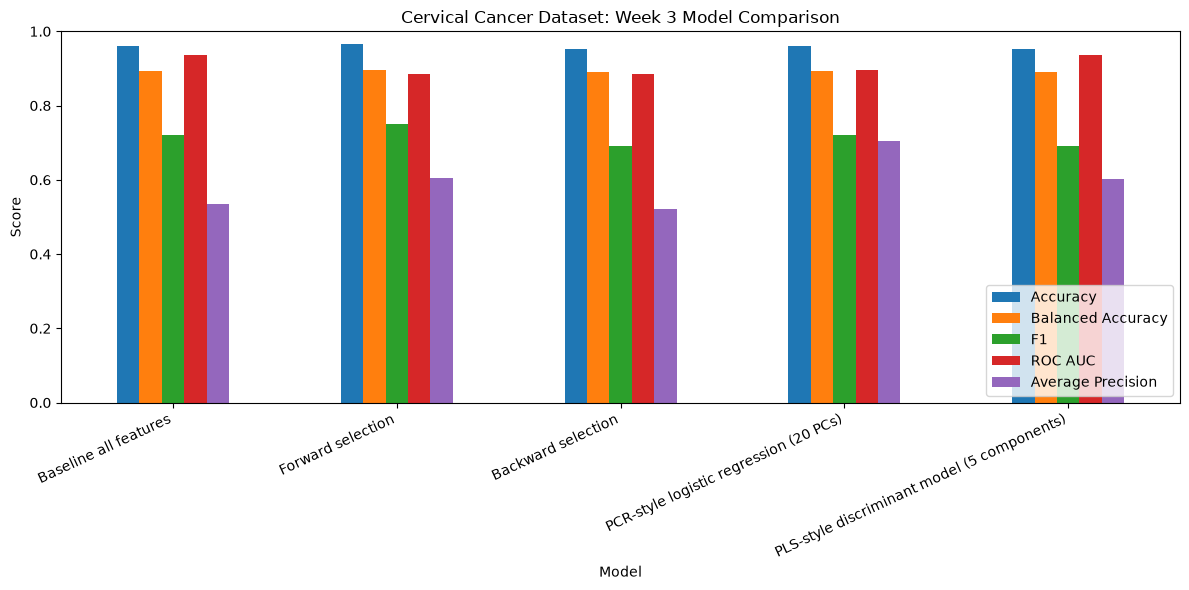

In [59]:
final_comparison.set_index("Model")[
    ["Accuracy", "Balanced Accuracy", "F1", "ROC AUC", "Average Precision"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Cervical Cancer Dataset: Week 3 Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

- The **final comparison plot** shows that the models are **close** on **accuracy**, **balanced accuracy**, and **recall-related performance**

- **Forward selection** has the best **F1 score**

- **PCR** has the best **average precision**

- **PLS** performs reasonably well with only **5 components**, but it does not dominate the other methods

- For this cervical cancer dataset, **both feature selection and dimensionality reduction are useful**, but they optimize different aspects of performance

#### [Dataset 3] | *18- Classification report for best average-precision model*

In [60]:
best_predictions = pcr_predictions

print(classification_report(
    y_test,
    best_predictions,
    digits=3,
    zero_division=0
))

pcr_confusion = pd.DataFrame(
    confusion_matrix(y_test, best_predictions),
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(pcr_confusion)

              precision    recall  f1-score   support

           0      0.987     0.969     0.978       161
           1      0.643     0.818     0.720        11

    accuracy                          0.959       172
   macro avg      0.815     0.894     0.849       172
weighted avg      0.965     0.959     0.962       172



,Predicted 0,Predicted 1
Actual 0,156,5
Actual 1,2,9


The best model by **average precision was the PCR-style logistic regression model with 20 principal components**

The executed classification report was:

| Class | Precision | Recall | F1-score | Support |
|---:|---:|---:|---:|---:|
| 0 | 0.987 | 0.969 | 0.978 | 161 |
| 1 | 0.643 | 0.818 | 0.720 | 11 |

Overall results:

| Metric | Value |
|---|---:|
| Accuracy | 0.959 |
| Macro F1 | 0.849 |
| Weighted F1 | 0.962 |

The executed confusion matrix was:

|  | Predicted 0 | Predicted 1 |
|---|---:|---:|
| Actual 0 | 156 | 5 |
| Actual 1 | 2 | 9 |


- The **PCR-style** model correctly identified **9 of the 11 biopsy-positive** cases and **missed 2 positive cases**. It also produced **5 false positives**

- This is a strong result for an **imbalanced medical classification task**

#### [Dataset 3] | *19- Summary*


- **Forward selection** produced the best F1 score, suggesting that a small group of predictors can perform very well for direct classification

- **PCR** produced the best average precision, suggesting it ranked positive biopsy cases best by predicted probability 

- **PLS-style** classification worked with only 5 components but did not outperform the strongest **feature-selection** or **PCR** model

- The **main takeaway** is that **feature selection and dimensionality reduction** are both useful, but they serve slightly different purposes

    - Forward selection was best for threshold-based classification, while PCR was best for probability ranking.